<a href="https://colab.research.google.com/github/jamermj/Nanowires/blob/main/MR_Notebook2_Diagnostic_Plots.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 2 — Diagnostic plots

Upload `MR_processed_outputs.zip` from Notebook 1. This notebook makes MR comparison plots and derivative plots.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import zipfile, os, re, shutil, glob
from google.colab import files

outdir = "MR_outputs"
if os.path.exists(outdir):
    shutil.rmtree(outdir)
os.makedirs(outdir, exist_ok=True)

uploaded = files.upload()
zipname = list(uploaded.keys())[0]
with zipfile.ZipFile(zipname, 'r') as z:
    z.extractall(outdir)

DATASET_CONFIGS = {
    "dataset1": {"CH2": "FL2F", "CH2_label": "FL2-F", "CH3": "GN22", "CH3_label": "GN2-2"},
    "dataset2": {"CH2": "GN23", "CH2_label": "GN2-3", "CH3": "FL2C3", "CH3_label": "FL2C3"}
}

def extract_temperature(filename):
    match = re.search(r'MRat\s*(\d+)K', filename)
    return int(match.group(1)) if match else None

Saving MR_processed_outputs.zip to MR_processed_outputs.zip


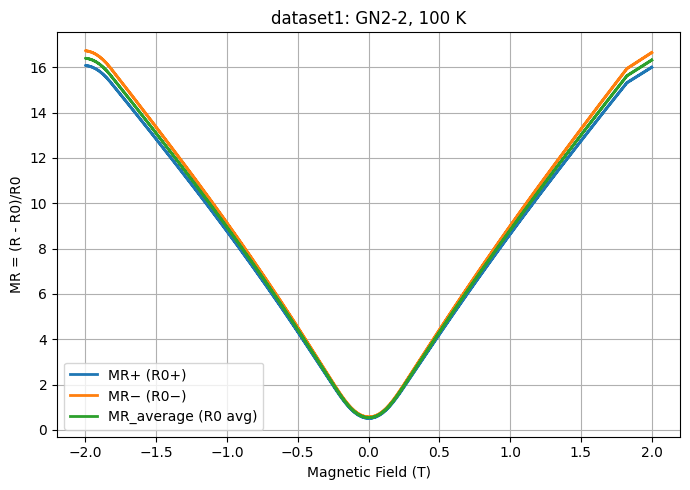

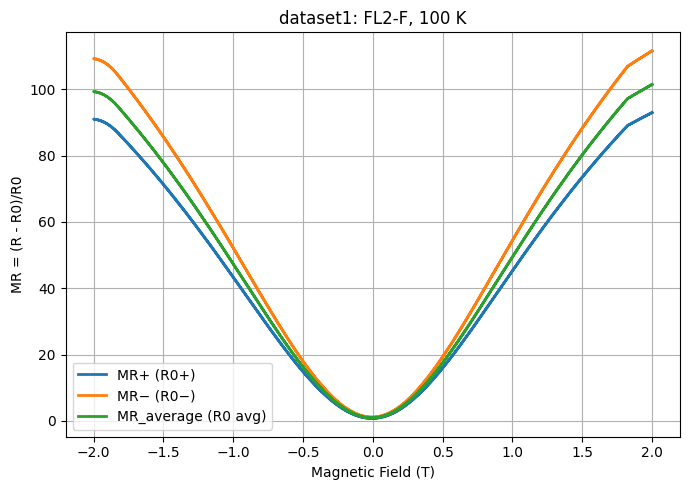

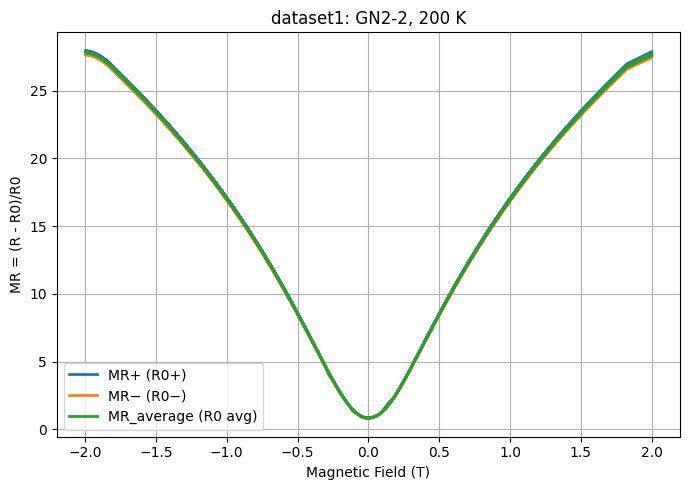

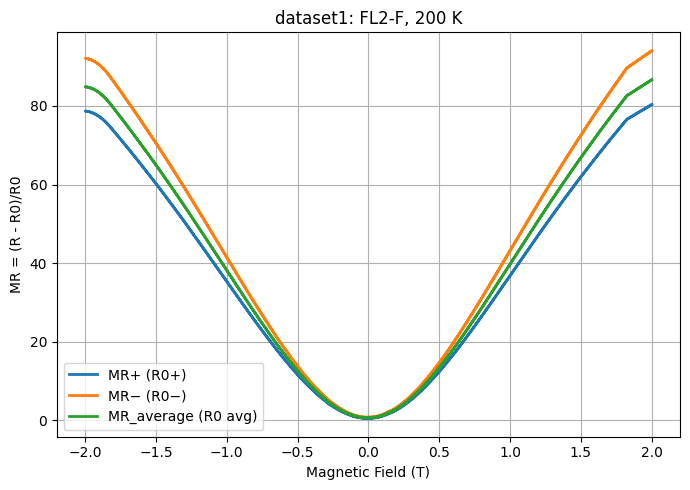

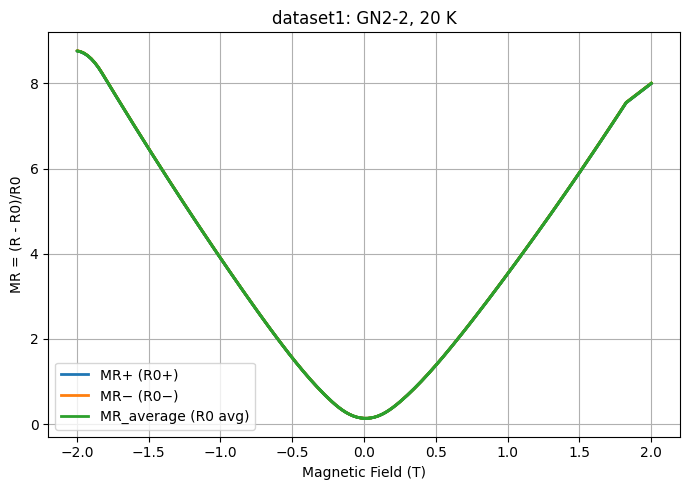

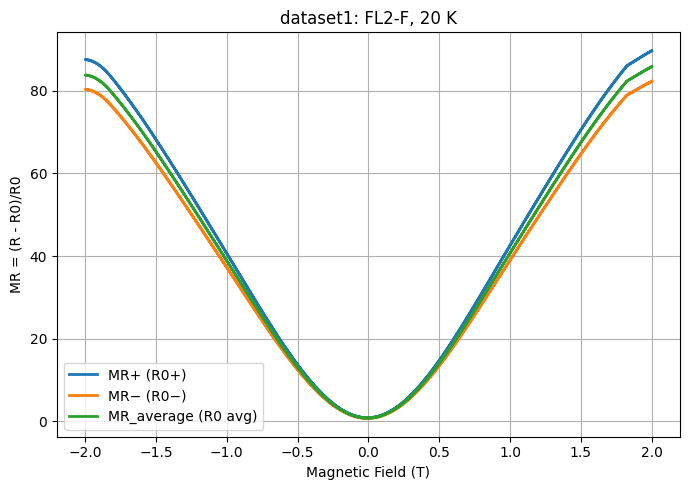

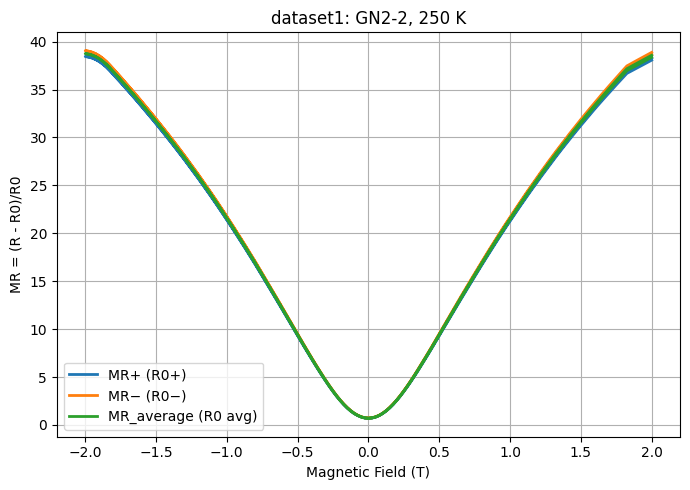

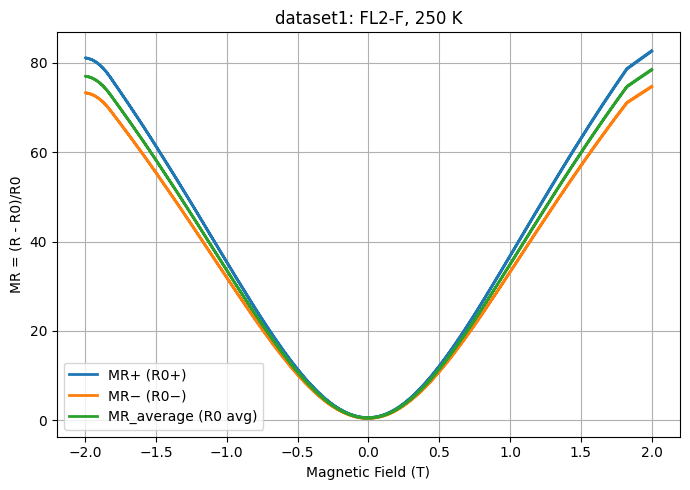

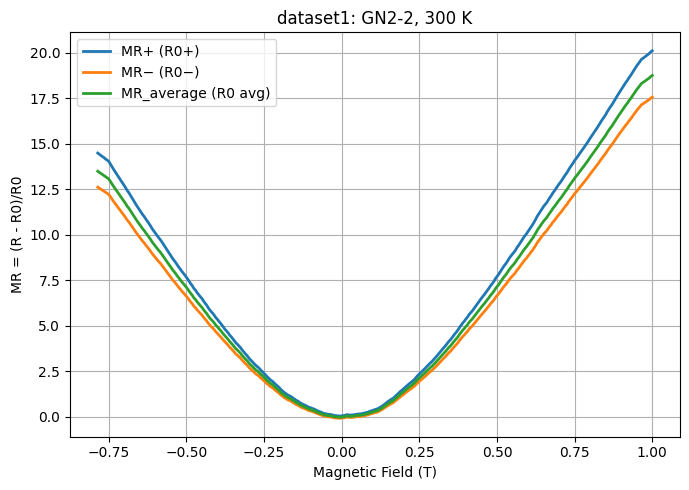

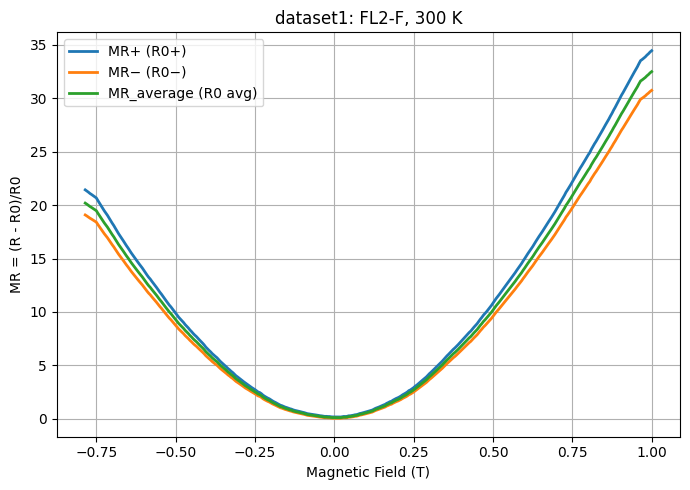

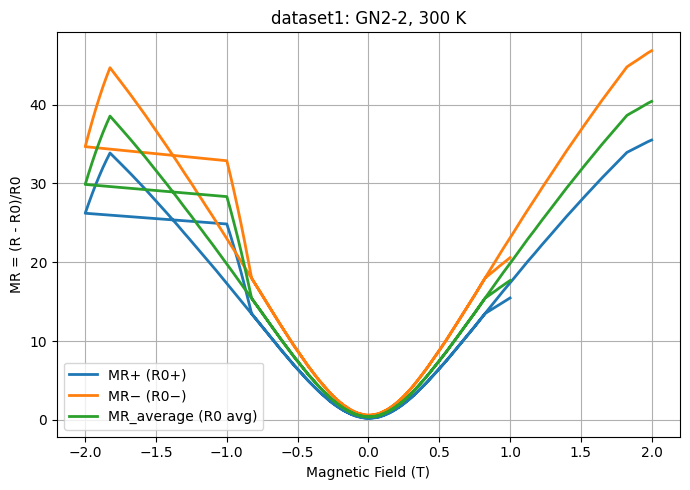

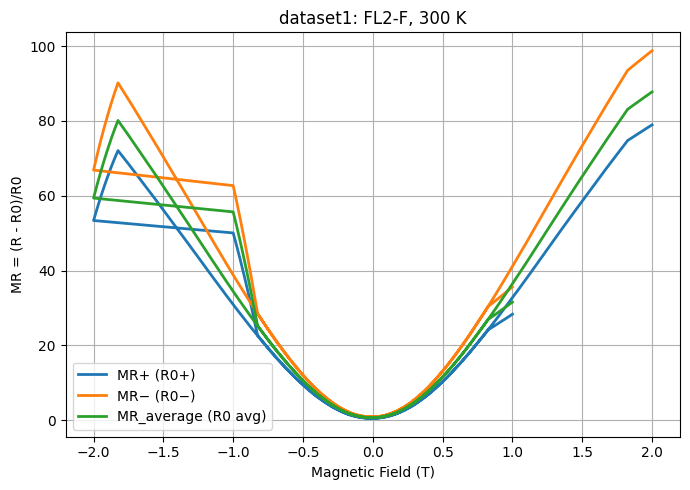

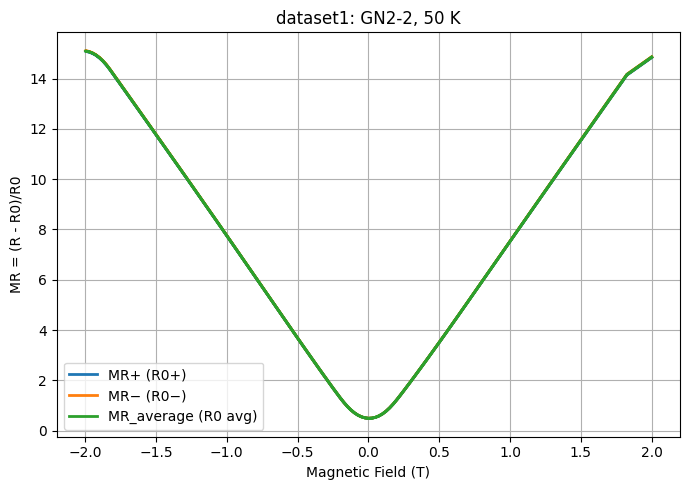

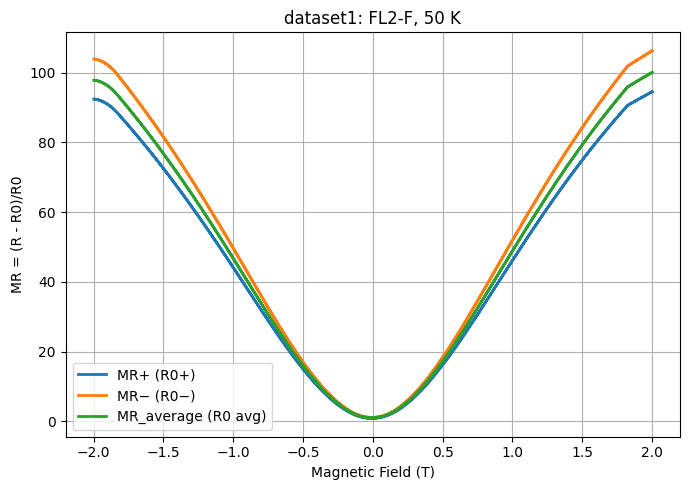

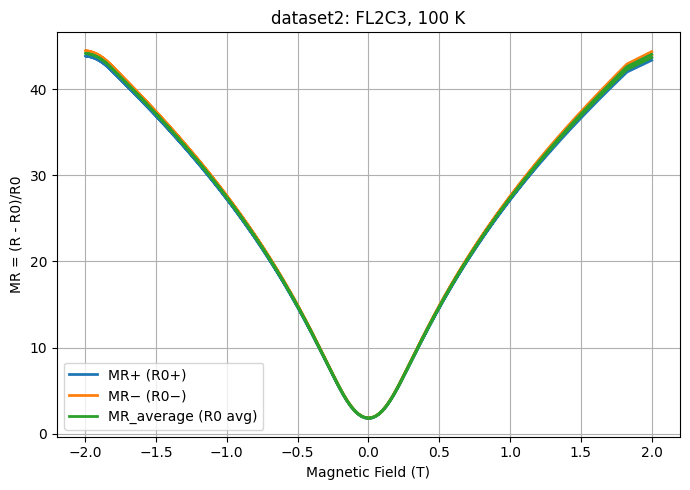

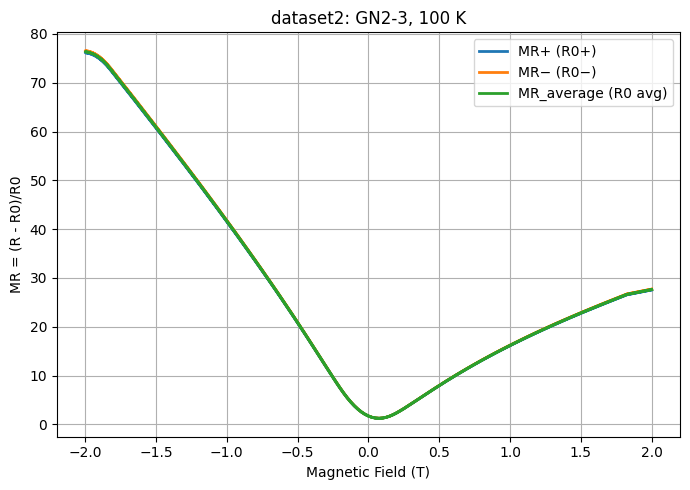

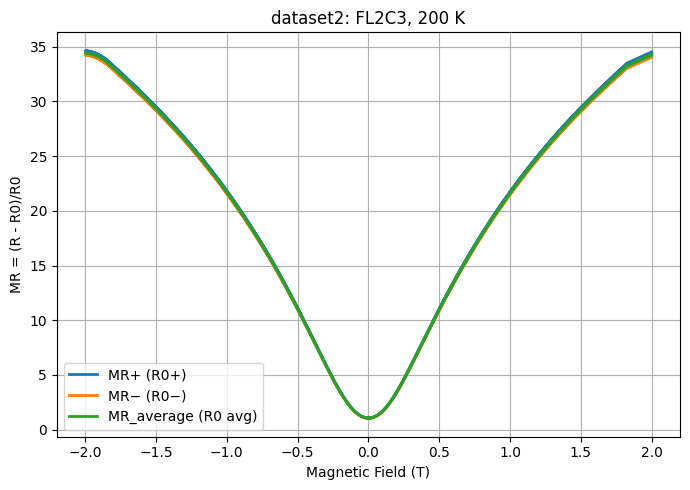

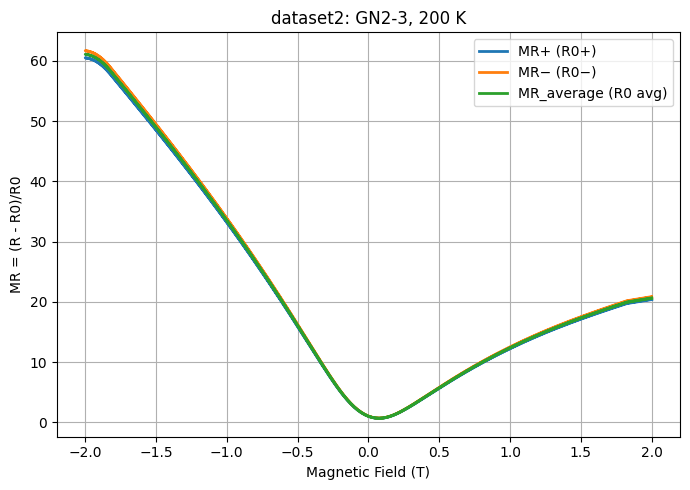

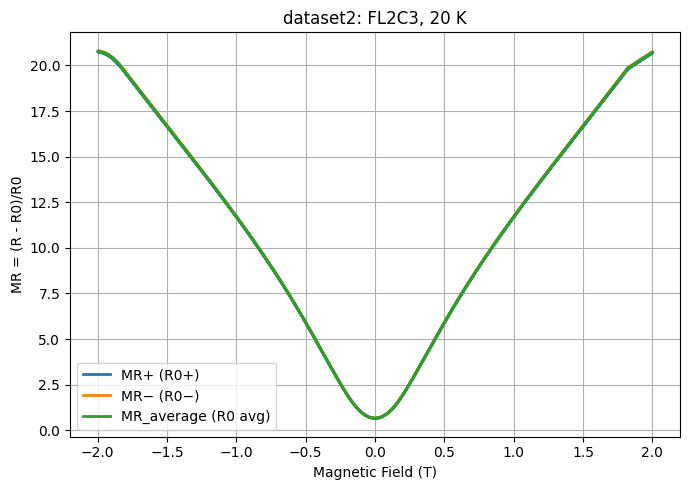

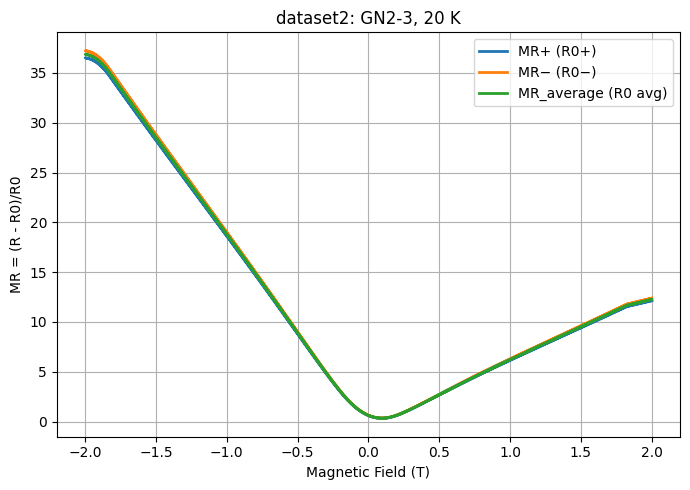

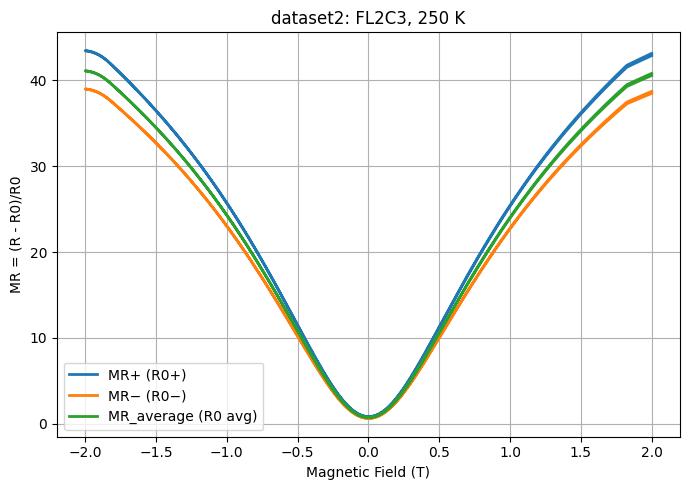

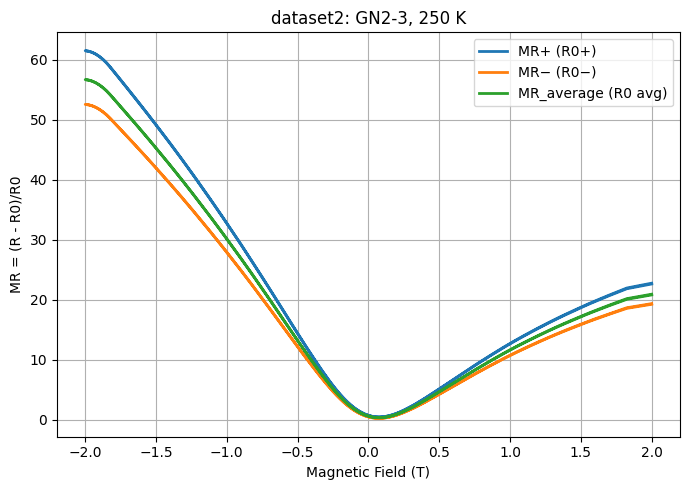

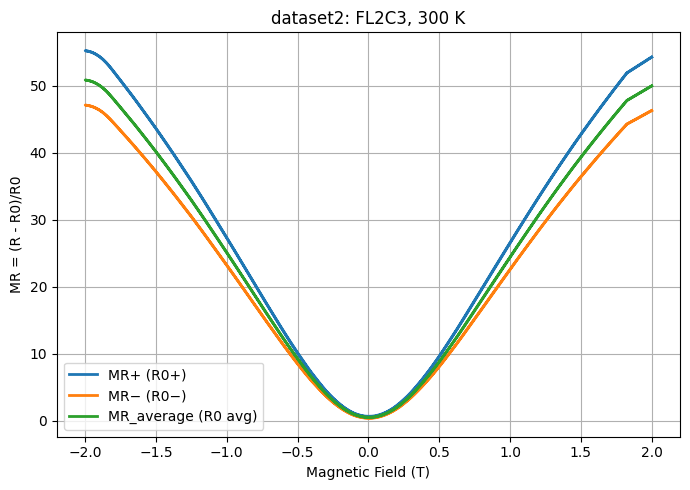

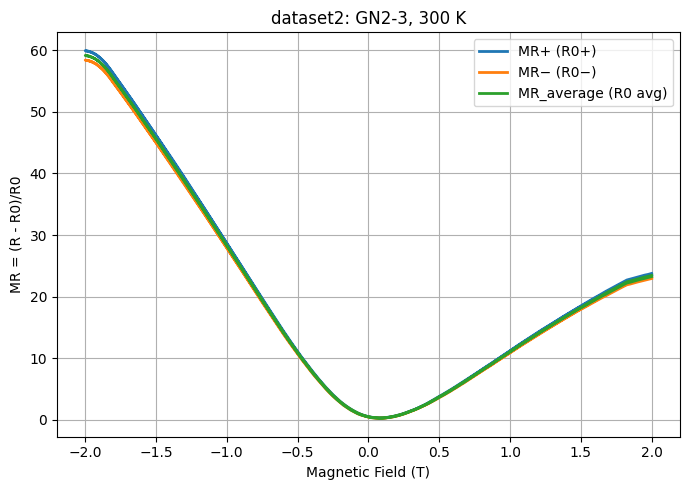

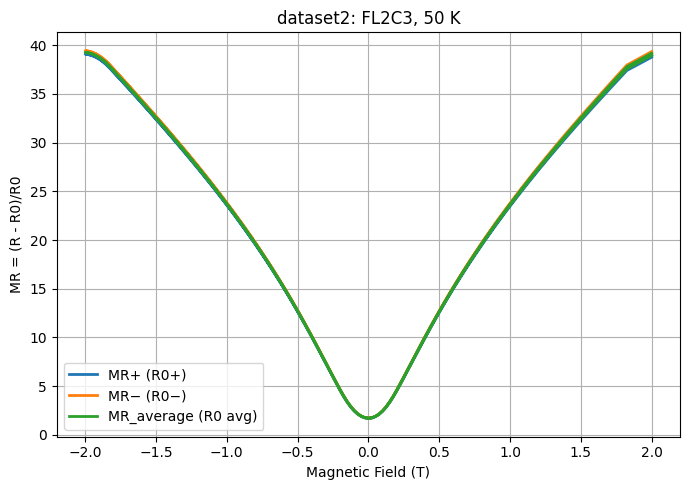

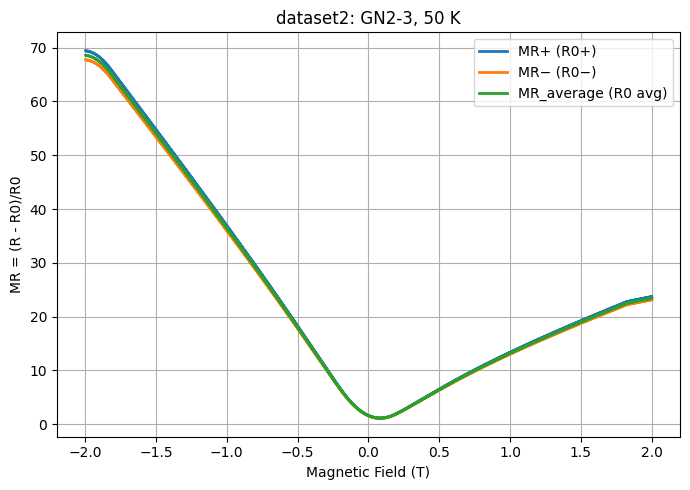

In [ ]:
# MR+, MR−, and MR_average for every sample and temperature
processed_files = glob.glob(os.path.join(outdir, "*_MR_derivatives.csv"))

for file in sorted(processed_files):
    fname = os.path.basename(file)
    dataset_key = fname.split("_")[0]
    T = extract_temperature(fname)
    df = pd.read_csv(file)
    cfg = DATASET_CONFIGS[dataset_key]

    samples = [(cfg["CH3"], cfg["CH3_label"]), (cfg["CH2"], cfg["CH2_label"])]

    for internal_sample, sample_label in samples:
        plt.figure(figsize=(7,5))
        plt.plot(df['Field_T'], df[f'MR_{internal_sample}_plus_smooth'], linewidth=2, label='MR+ (R0+)')
        plt.plot(df['Field_T'], df[f'MR_{internal_sample}_minus_smooth'], linewidth=2, label='MR− (R0−)')
        plt.plot(df['Field_T'], df[f'MR_{internal_sample}_average_smooth'], linewidth=2, label='MR_average (R0 avg)')
        plt.xlabel('Magnetic Field (T)')
        plt.ylabel('MR = (R - R0)/R0')
        plt.title(f'{dataset_key}: {sample_label}, {T} K')
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.savefig(os.path.join(outdir, f'{dataset_key}_{sample_label}_{T}K_MR_plus_minus_average.png'), dpi=300)
        plt.show()

In [ ]:
# All four samples on same average-MR graph at each temperature
processed_files = glob.glob(os.path.join(outdir, "*_MR_derivatives.csv"))
temp_data = {}

for file in sorted(processed_files):
    fname = os.path.basename(file)
    dataset_key = fname.split("_")[0]
    T = extract_temperature(fname)
    df = pd.read_csv(file)
    cfg = DATASET_CONFIGS[dataset_key]
    samples = [(cfg["CH3"], cfg["CH3_label"]), (cfg["CH2"], cfg["CH2_label"])]

    temp_data.setdefault(T, [])
    for internal_sample, sample_label in samples:
        temp_data[T].append({
            'label': sample_label,
            'Field_T': df['Field_T'],
            'MR_average': df[f'MR_{internal_sample}_average_smooth']
        })

for T in sorted(temp_data):
    plt.figure(figsize=(7,5))
    for item in temp_data[T]:
        plt.plot(item['Field_T'], item['MR_average'], linewidth=2, label=item['label'])
    plt.xlabel('Magnetic Field (T)')
    plt.ylabel('MR_average')
    plt.title(f'Average MR comparison, {T} K')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(outdir, f'Average_MR_comparison_all_samples_{T}K.png'), dpi=300)
    plt.show()

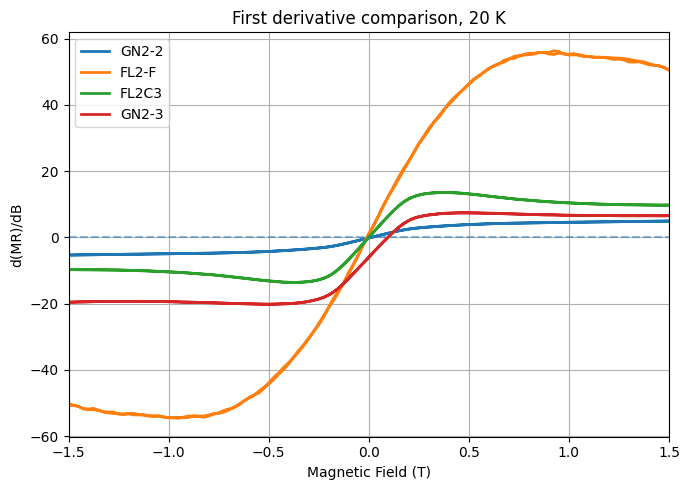

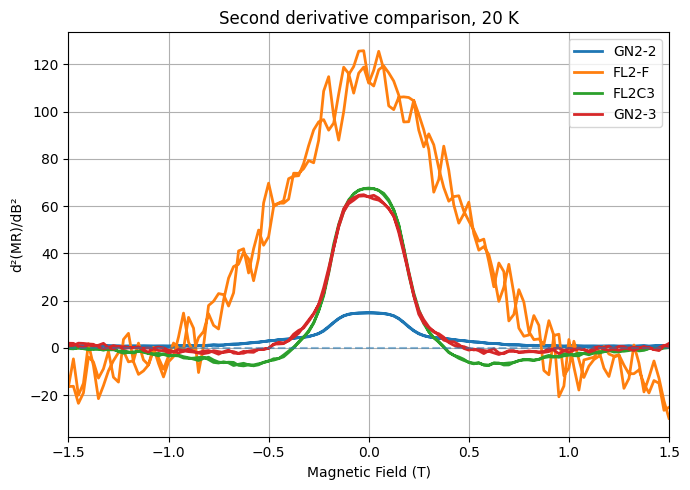

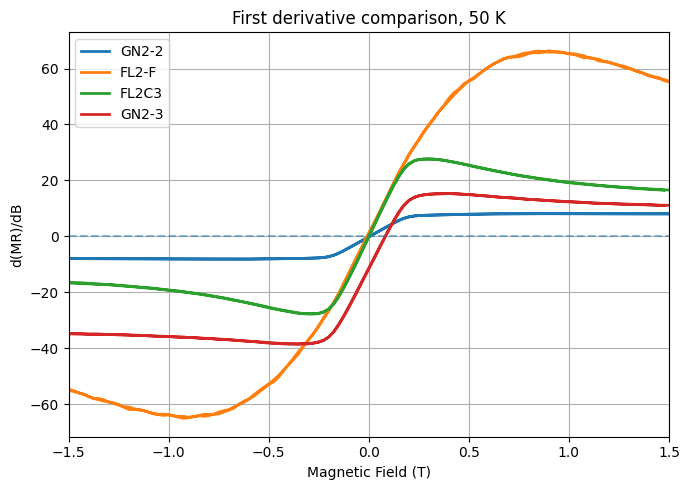

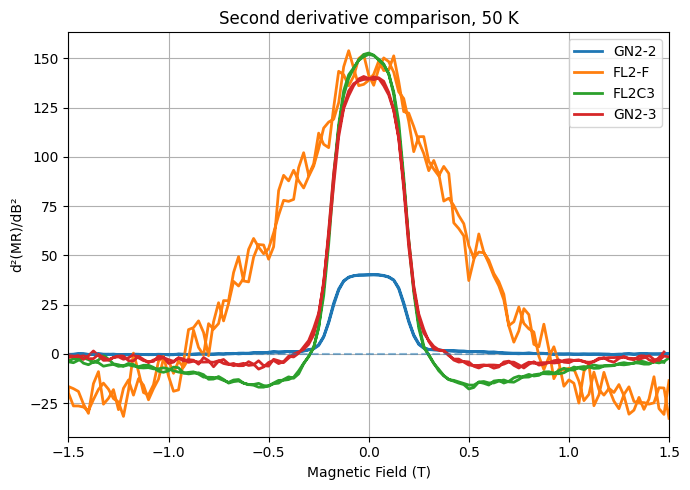

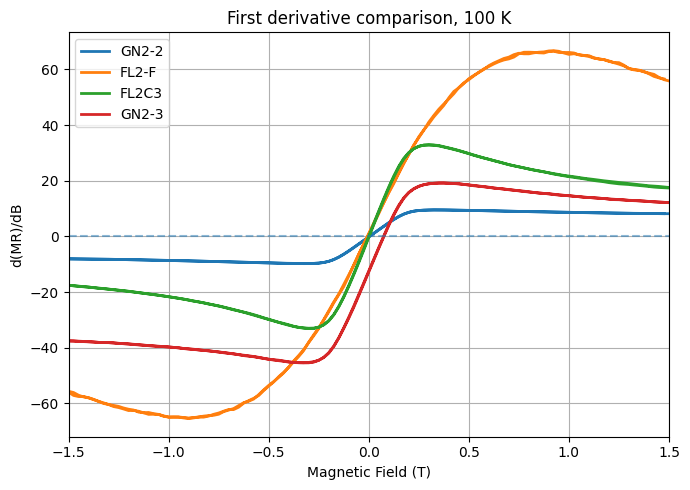

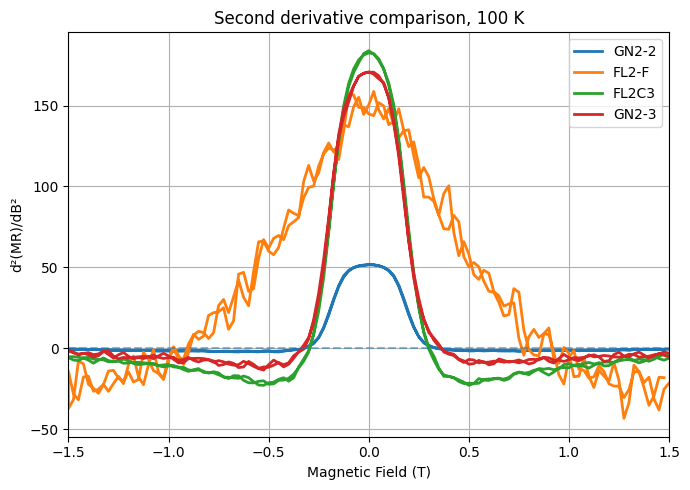

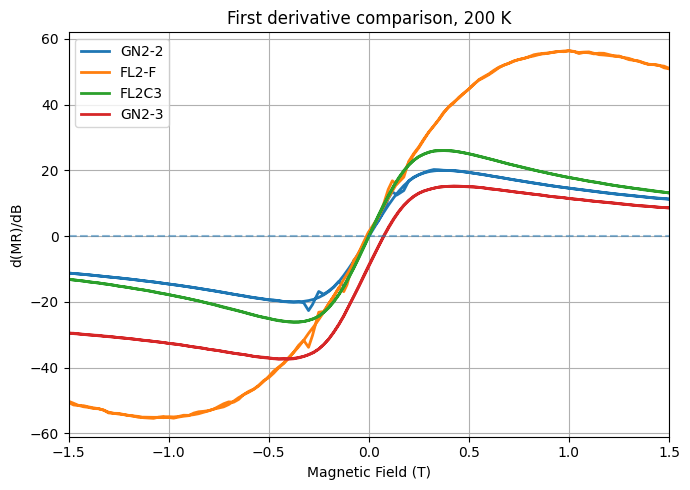

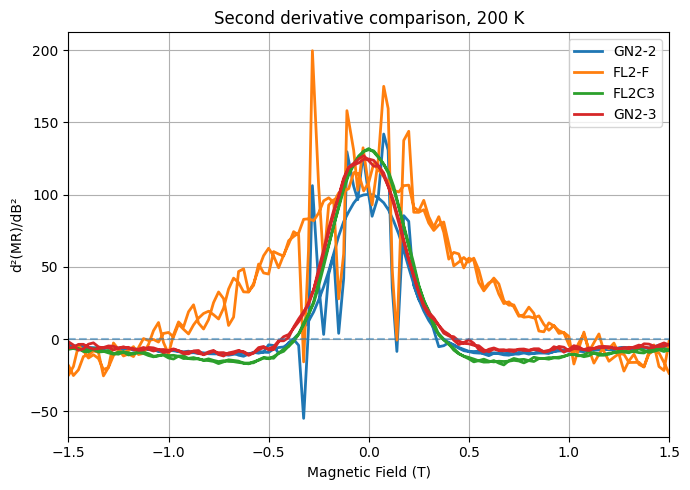

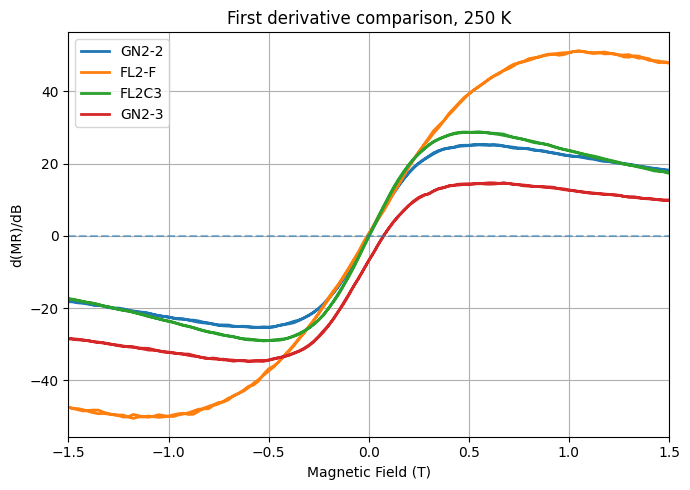

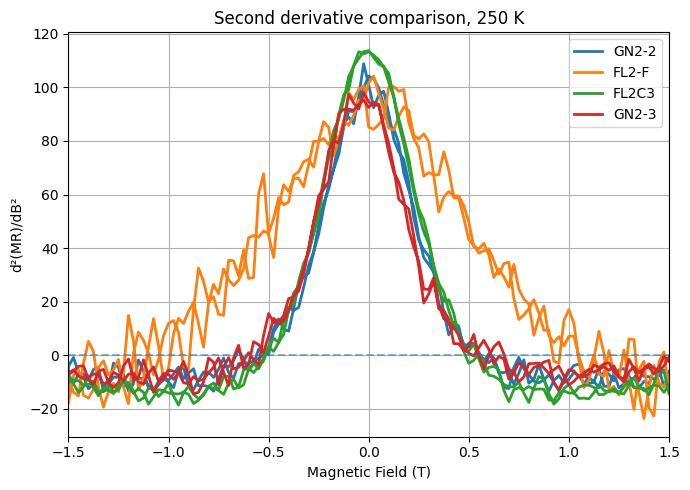

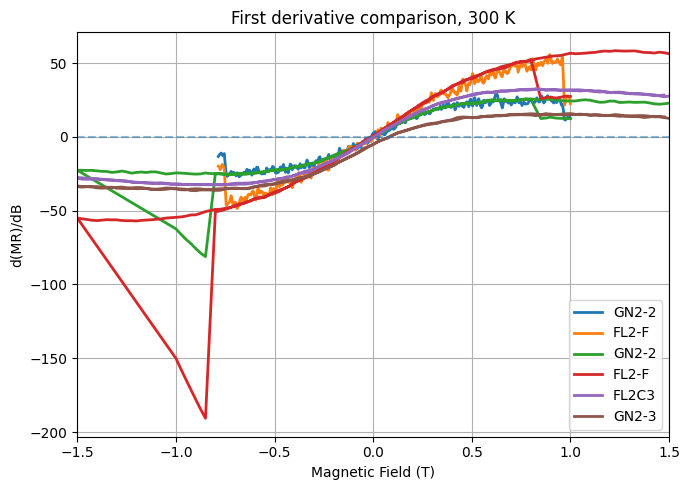

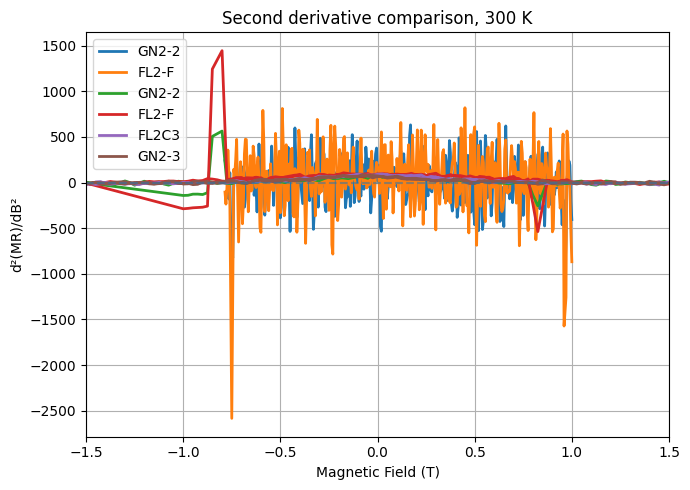

In [ ]:
# Combined first and second derivatives for all four samples at each temperature
REMOVE_DATASET1_300K_OUTLIER = True
combined_derivative_data = {}

for file in sorted(processed_files):
    fname = os.path.basename(file)
    dataset_key = fname.split("_")[0]
    T = extract_temperature(fname)
    df = pd.read_csv(file)
    cfg = DATASET_CONFIGS[dataset_key]
    samples = [(cfg["CH3"], cfg["CH3_label"]), (cfg["CH2"], cfg["CH2_label"])]

    combined_derivative_data.setdefault(T, [])
    for internal_sample, sample_label in samples:
        plot_df = df[(df['Field_T'] >= -1.5) & (df['Field_T'] <= 1.5)].copy()

        if REMOVE_DATASET1_300K_OUTLIER and dataset_key == 'dataset1' and T == 300:
            deriv_col = f'd2MRdB2_{internal_sample}'
            if deriv_col in plot_df.columns and len(plot_df) > 5:
                outlier_idx = plot_df[deriv_col].abs().idxmax()
                plot_df = plot_df.drop(index=outlier_idx)

        combined_derivative_data[T].append({
            'label': sample_label,
            'Field_T': plot_df['Field_T'],
            'dMRdB': plot_df[f'dMRdB_{internal_sample}'],
            'd2MRdB2': plot_df[f'd2MRdB2_{internal_sample}']
        })

for T in sorted(combined_derivative_data):
    plt.figure(figsize=(7,5))
    for item in combined_derivative_data[T]:
        plt.plot(item['Field_T'], item['dMRdB'], linewidth=2, label=item['label'])
    plt.axhline(0, linestyle='--', alpha=0.5)
    plt.xlabel('Magnetic Field (T)')
    plt.ylabel('d(MR)/dB')
    plt.title(f'First derivative comparison, {T} K')
    plt.xlim(-1.5, 1.5)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(outdir, f'All_samples_first_derivative_{T}K_pm1p5T.png'), dpi=300)
    plt.show()

    plt.figure(figsize=(7,5))
    for item in combined_derivative_data[T]:
        plt.plot(item['Field_T'], item['d2MRdB2'], linewidth=2, label=item['label'])
    plt.axhline(0, linestyle='--', alpha=0.5)
    plt.xlabel('Magnetic Field (T)')
    plt.ylabel('d²(MR)/dB²')
    plt.title(f'Second derivative comparison, {T} K')
    plt.xlim(-1.5, 1.5)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(outdir, f'All_samples_second_derivative_{T}K_pm1p5T.png'), dpi=300)
    plt.show()

In [ ]:
# Zip diagnostic plots
zip_out = "MR_diagnostic_plots.zip"
with zipfile.ZipFile(zip_out, 'w') as z:
    for root, dirs, filenames in os.walk(outdir):
        for f in filenames:
            fullpath = os.path.join(root, f)
            z.write(fullpath, arcname=os.path.relpath(fullpath, outdir))
files.download(zip_out)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>